# Intake Catalogs

Intake **catalogs are structures** which make navigating the different models, experiments, output variables etc. much easier than clicking through the folder structure. You can easily browse data in the shared folders on the jupyterhub.

In [1]:
#import necessary packages
import intake_esm
import intake
import pandas
import xarray
import gcsfs
import matplotlib as mpl
import cartopy.crs as ccrs
import warnings
#suppress some annoying future warning
warnings.filterwarnings("ignore", category=FutureWarning)


The intake catalog corresponding to the CMIP6 files  under `~/shared-tacco-ns1004k-cmip*` is

In [2]:
cmip6_catalog_path = '/mnt/tacco-ns1004k/catalogs/merged_local.json'
cmip6_catalog = intake.open_esm_datastore(cmip6_catalog_path)
cmip6_catalog

,unique
variable_id,329
table_id,23
source_id,73
experiment_id,23
member_id,189
grid_label,11
time_range,7657
activity_id,4
institution_id,34
version,528


The left column are the attributes of all files included in the catalog. The 'unique' column tells you how many unique, i.e. different, versions of each attributes exist amongst the files. You can print all entries of each of the attributes to see what is available:

In [3]:
unique = cmip6_catalog.unique()
unique['experiment_id']

['1pctCO2',
 'abrupt-4xCO2',
 'amip',
 'historical',
 'piControl',
 'esm-hist',
 'esm-piControl',
 'ssp126',
 'ssp585',
 'esm-piControl-spinup',
 'piControl-spinup',
 'histSST',
 'piClim-2xDMS',
 'piClim-2xVOC',
 'hist-GHG',
 'hist-nat',
 'GISS-E2-1-G',
 'ssp245',
 'ssp370',
 'ssp119',
 'ssp534-over',
 'ssp434',
 'ssp460']

You can also create a **subset** of your catalog by specifying attributes through the **.search()** function

In [4]:
cat_subset = cmip6_catalog.search(
    experiment_id = "historical",
    table_id = "Lmon",
    variable_id = "tsl"
)
cat_subset.unique()

variable_id                                                        [tsl]
table_id                                                          [Lmon]
source_id              [TaiESM1, BCC-CSM2-MR, BCC-ESM1, FGOALS-f3-L, ...
experiment_id                                               [historical]
member_id              [r1i1p1f1, r1i1p2f1, r1i1p1f2, r1i1p1f3, r4i1p...
grid_label                                                      [gn, gr]
time_range             [185002-201412, 185001-192912, 193001-201412, ...
activity_id               [tacco-ns1004k-cmip, tacco-ns1004k-cmip-betzy]
institution_id         [AS-RCEC, BCC, CAS, CCCma, CNRM-CERFACS, CSIRO...
version                [20200218, 20181114, 20190821, 20190429, 20191...
path                   [/mnt/tacco-ns1004k-cmip/AS-RCEC/TaiESM1/histo...
dcpp_init_year                                                        []
format                                                          [netcdf]
derived_variable_id                                

You can also **inspect** the catalog by looking at its underlying pandas dataframe. 

In [5]:
cmip6_catalog.df

,variable_id,table_id,source_id,experiment_id,member_id,grid_label,time_range,activity_id,institution_id,version,path,dcpp_init_year,format
0,tas,Amon,TaiESM1,1pctCO2,r1i1p1f1,gn,000101-015012,tacco-ns1004k-cmip,AS-RCEC,20200225,/mnt/tacco-ns1004k-cmip/AS-RCEC/TaiESM1/1pctCO...,NaN,netcdf
1,hus,Amon,TaiESM1,abrupt-4xCO2,r1i1p1f1,gn,000101-015012,tacco-ns1004k-cmip,AS-RCEC,20200310,/mnt/tacco-ns1004k-cmip/AS-RCEC/TaiESM1/abrupt...,NaN,netcdf
2,pr,Amon,TaiESM1,abrupt-4xCO2,r1i1p1f1,gn,000101-015012,tacco-ns1004k-cmip,AS-RCEC,20200310,/mnt/tacco-ns1004k-cmip/AS-RCEC/TaiESM1/abrupt...,NaN,netcdf
3,rlut,Amon,TaiESM1,abrupt-4xCO2,r1i1p1f1,gn,000101-015012,tacco-ns1004k-cmip,AS-RCEC,20200310,/mnt/tacco-ns1004k-cmip/AS-RCEC/TaiESM1/abrupt...,NaN,netcdf
4,rlutcs,Amon,TaiESM1,abrupt-4xCO2,r1i1p1f1,gn,000101-015012,tacco-ns1004k-cmip,AS-RCEC,20200310,/mnt/tacco-ns1004k-cmip/AS-RCEC/TaiESM1/abrupt...,NaN,netcdf
...,...,...,...,...,...,...,...,...,...,...,...,...,...
849532,sosga,Omon,MCM-UA-1-0,ssp585,r1i1p1f2,gn,201501-210012,tacco-ns1004k-cmip-betzy2,UA,20190731,/mnt/tacco-ns1004k-cmip-betzy2/UA/MCM-UA-1-0/s...,NaN,netcdf
849533,thetao,Omon,MCM-UA-1-0,ssp585,r1i1p1f2,gn,201501-210012,tacco-ns1004k-cmip-betzy2,UA,20190731,/mnt/tacco-ns1004k-cmip-betzy2/UA/MCM-UA-1-0/s...,NaN,netcdf
849534,tos,Omon,MCM-UA-1-0,ssp585,r1i1p1f2,gn,201501-210012,tacco-ns1004k-cmip-betzy2,UA,20190731,/mnt/tacco-ns1004k-cmip-betzy2/UA/MCM-UA-1-0/s...,NaN,netcdf
849535,tosga,Omon,MCM-UA-1-0,ssp585,r1i1p1f2,gn,201501-210012,tacco-ns1004k-cmip-betzy2,UA,20190731,/mnt/tacco-ns1004k-cmip-betzy2/UA/MCM-UA-1-0/s...,NaN,netcdf


**Pandas dataframes** have the **.head()** and **.tail()** functions to inspect the first and last 5 rows.

- learn more about the pandas package and the options you have with it!

In [10]:
cmip6_catalog.df.head()

,variable_id,table_id,source_id,experiment_id,member_id,grid_label,time_range,activity_id,institution_id,version,path,dcpp_init_year,format
0,tas,Amon,TaiESM1,1pctCO2,r1i1p1f1,gn,000101-015012,tacco-ns1004k-cmip,AS-RCEC,20200225,/mnt/tacco-ns1004k-cmip/AS-RCEC/TaiESM1/1pctCO...,NaN,netcdf
1,hus,Amon,TaiESM1,abrupt-4xCO2,r1i1p1f1,gn,000101-015012,tacco-ns1004k-cmip,AS-RCEC,20200310,/mnt/tacco-ns1004k-cmip/AS-RCEC/TaiESM1/abrupt...,NaN,netcdf
2,pr,Amon,TaiESM1,abrupt-4xCO2,r1i1p1f1,gn,000101-015012,tacco-ns1004k-cmip,AS-RCEC,20200310,/mnt/tacco-ns1004k-cmip/AS-RCEC/TaiESM1/abrupt...,NaN,netcdf
3,rlut,Amon,TaiESM1,abrupt-4xCO2,r1i1p1f1,gn,000101-015012,tacco-ns1004k-cmip,AS-RCEC,20200310,/mnt/tacco-ns1004k-cmip/AS-RCEC/TaiESM1/abrupt...,NaN,netcdf
4,rlutcs,Amon,TaiESM1,abrupt-4xCO2,r1i1p1f1,gn,000101-015012,tacco-ns1004k-cmip,AS-RCEC,20200310,/mnt/tacco-ns1004k-cmip/AS-RCEC/TaiESM1/abrupt...,NaN,netcdf


#### Lets load a catalog subset as a dataset dictionary


In [11]:
cat_subset = cmip6_catalog.search(
    experiment_id = "historical",
    table_id = "Amon",
    variable_id = "tas",
    source_id = "CESM2"
)
cat_subset.unique()

variable_id                                                        [tas]
table_id                                                          [Amon]
source_id                                                        [CESM2]
experiment_id                                               [historical]
member_id              [r10i1p1f1, r11i1p1f1, r1i1p1f1, r2i1p1f1, r3i...
grid_label                                                          [gn]
time_range             [185001-189912, 190001-194912, 195001-199912, ...
activity_id               [tacco-ns1004k-cmip, tacco-ns1004k-cmip-betzy]
institution_id                                                    [NCAR]
version                                   [20190313, 20190514, 20190308]
path                   [/mnt/tacco-ns1004k-cmip/NCAR/CESM2/historical...
dcpp_init_year                                                        []
format                                                          [netcdf]
derived_variable_id                                

#### We have several members, so let's reduce our subset to just one.

In [12]:
# We will reassign cat_subset here:
cat_subset = cat_subset.search( member_id='r1i1p1f1')
cat_subset.unique()

variable_id                                                        [tas]
table_id                                                          [Amon]
source_id                                                        [CESM2]
experiment_id                                               [historical]
member_id                                                     [r1i1p1f1]
grid_label                                                          [gn]
time_range                                               [185001-201412]
activity_id               [tacco-ns1004k-cmip, tacco-ns1004k-cmip-betzy]
institution_id                                                    [NCAR]
version                                                       [20190308]
path                   [/mnt/tacco-ns1004k-cmip/NCAR/CESM2/historical...
dcpp_init_year                                                        []
format                                                          [netcdf]
derived_variable_id                                

#### We can look at the files where the data is located by checking `path` column:

In [14]:
cat_subset.unique()["path"]

['/mnt/tacco-ns1004k-cmip/NCAR/CESM2/historical/r1i1p1f1/Amon/tas/gn/v20190308/tas_Amon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc',
 '/mnt/tacco-ns1004k-cmip-betzy/NCAR/CESM2/historical/r1i1p1f1/Amon/tas/gn/v20190308/tas_Amon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc']

#### Now, we can load the dataset throught xarray dirctly from path, or get it through intake:

In [17]:
# Two netCDF files above are actually the same, so we can load just the first one.
file_path = cat_subset.unique()["path"][0]
print(file_path)
tas_from_file = xarray.open_dataset(file_path)
tas_from_file

/mnt/tacco-ns1004k-cmip/NCAR/CESM2/historical/r1i1p1f1/Amon/tas/gn/v20190308/tas_Amon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc


/opt/conda/envs/labs/lib/python3.11/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


<xarray.Dataset> Size: 438MB
Dimensions:    (time: 1980, lat: 192, lon: 288, nbnd: 2)
Coordinates:
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * time       (time) object 16kB 1850-01-15 12:00:00 ... 2014-12-15 12:00:00
Dimensions without coordinates: nbnd
Data variables:
    tas        (time, lat, lon) float32 438MB ...
    time_bnds  (time, nbnd) object 32kB ...
    lat_bnds   (lat, nbnd) float32 2kB ...
    lon_bnds   (lon, nbnd) float32 2kB ...
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    case_id:                15
    cesm_casename:          b.e21.BHIST.f09_g17.CMIP6-historical.001
    contact:                cesm_cmip6@ucar.edu
    creation_date:          2019-01-16T23:34:05Z
    ...                     ...
    sub_experiment:         none
    sub_experiment_id:      none
    branch_time_in_parent:  219000.0
    branch_time_in_child:   674885.0
    branch_method:          standard
    further_info_url:       https://furtherinfo.es-doc.org/CMIP6.NCAR.CESM2.h...

In [53]:
#first we load dataset dictionary
dset_dict = cat_subset.to_dataset_dict()
#check what datasets we have in a dictionary
dset_dict.keys()


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


/opt/conda/envs/labs/lib/python3.11/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


dict_keys(['tacco-ns1004k-cmip-betzy.NCAR.CESM2.historical.Amon.gn', 'tacco-ns1004k-cmip.NCAR.CESM2.historical.Amon.gn'])

In [26]:
# here, we get just one dataset from the dictionary by it's key:
key = list(dset_dict.keys())[1]
print(key)
tas_from_intake = dset_dict[key]

tacco-ns1004k-cmip-betzy.NCAR.CESM2.historical.Amon.gn


In [27]:
tas_from_intake

<xarray.Dataset> Size: 438MB
Dimensions:         (member_id: 1, dcpp_init_year: 1, time: 1980, lat: 192,
                     lon: 288, nbnd: 2)
Coordinates:
  * lat             (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon             (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * time            (time) object 16kB 1850-01-15 12:00:00 ... 2014-12-15 12:...
  * member_id       (member_id) object 8B 'r1i1p1f1'
  * dcpp_init_year  (dcpp_init_year) float64 8B nan
Dimensions without coordinates: nbnd
Data variables:
    tas             (member_id, dcpp_init_year, time, lat, lon) float32 438MB dask.array<chunksize=(1, 1, 1, 192, 288), meta=np.ndarray>
    time_bnds       (time, nbnd) object 32kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds        (lat, nbnd) float32 2kB dask.array<chunksize=(192, 2), meta=np.ndarray>
    lon_bnds        (lon, nbnd) float32 2kB dask.array<chunksize=(288, 2), meta=np.ndarray>
Attributes: (12/59)
    Conventions:                      CF-1.7 CMIP-6.2
    activity_id:                      CMIP
    case_id:                          15
    cesm_casename:                    b.e21.BHIST.f09_g17.CMIP6-historical.001
    contact:                          cesm_cmip6@ucar.edu
    creation_date:                    2019-01-16T23:34:05Z
    ...                               ...
    intake_esm_attrs:activity_id:     tacco-ns1004k-cmip-betzy
    intake_esm_attrs:institution_id:  NCAR
    intake_esm_attrs:version:         20190308
    intake_esm_attrs:path:            /mnt/tacco-ns1004k-cmip-betzy/NCAR/CESM...
    intake_esm_attrs:_data_format_:   netcdf
    intake_esm_dataset_key:           tacco-ns1004k-cmip-betzy.NCAR.CESM2.his...

#### You can see that both of these are the same, the fake "activity_id"  here is just a head of the path to the datasets and the dataset is actually duplicated in both folders.

#### Now, lets subset time in two different ways:

In [ ]:
# first, as you can see in the attributes of `time` variable on the dataset, 

In [34]:
tas_2000=tas_from_file.tas.sel(time=slice("2000-01", "2000-01"))

In [35]:
# We did not need ti soecify the exect date here:
tas_2000

<xarray.DataArray 'tas' (time: 1, lat: 192, lon: 288)> Size: 221kB
[55296 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * time     (time) object 8B 2000-01-15 12:00:00
Attributes: (12/19)
    cell_measures:  area: areacella
    cell_methods:   area: time: mean
    comment:        near-surface (usually, 2 meter) air temperature
    description:    near-surface (usually, 2 meter) air temperature
    frequency:      mon
    id:             tas
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Near-Surface Air Temperature
    type:           real
    units:          K
    variable_id:    tas

#### Slicing is useful if you want to get a small time range out of a dataset
#### If we want to find a record closets to some date, we can use cftime module

In [36]:
import cftime as cft

In [42]:
date = cft.DatetimeNoLeap(2000,1,1)
date

cftime.DatetimeNoLeap(2000, 1, 1, 0, 0, 0, 0, has_year_zero=True)

In [44]:
tas_2000=tas_from_file.tas.sel(time=date,method='nearest')
tas_2000

<xarray.DataArray 'tas' (lat: 192, lon: 288)> Size: 221kB
[55296 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
    time     object 8B 2000-01-15 12:00:00
Attributes: (12/19)
    cell_measures:  area: areacella
    cell_methods:   area: time: mean
    comment:        near-surface (usually, 2 meter) air temperature
    description:    near-surface (usually, 2 meter) air temperature
    frequency:      mon
    id:             tas
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Near-Surface Air Temperature
    type:           real
    units:          K
    variable_id:    tas

#### We can also use interpolation methods for space coordinates.

In [47]:
tas_oslo=tas_from_file.sel(lat=5.913,lon=10.739, method="nearest")

In [48]:
tas_oslo

<xarray.Dataset> Size: 55kB
Dimensions:    (time: 1980, nbnd: 2)
Coordinates:
    lat        float64 8B 6.126
    lon        float64 8B 11.25
  * time       (time) object 16kB 1850-01-15 12:00:00 ... 2014-12-15 12:00:00
Dimensions without coordinates: nbnd
Data variables:
    tas        (time) float32 8kB ...
    time_bnds  (time, nbnd) object 32kB ...
    lat_bnds   (nbnd) float32 8B ...
    lon_bnds   (nbnd) float32 8B ...
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    case_id:                15
    cesm_casename:          b.e21.BHIST.f09_g17.CMIP6-historical.001
    contact:                cesm_cmip6@ucar.edu
    creation_date:          2019-01-16T23:34:05Z
    ...                     ...
    sub_experiment:         none
    sub_experiment_id:      none
    branch_time_in_parent:  219000.0
    branch_time_in_child:   674885.0
    branch_method:          standard
    further_info_url:       https://furtherinfo.es-doc.org/CMIP6.NCAR.CESM2.h...

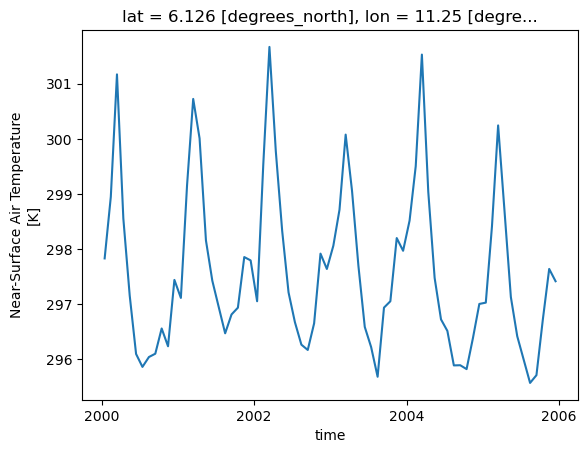

In [51]:
tas_oslo.tas.sel(time=slice("2000-01","2005-12")).plot()